# Homework 10b: Time-Series Classification
Predict whether next-day AAPL return is positive using past-only features and a chronological split.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
P=Path.cwd().resolve(); P=P if P.name=='homework10b' else P/'homework'/'homework10b'
df=pd.read_csv(P.parent/'homework09/data/processed/aapl_features.csv',parse_dates=['date']).sort_values('date')
features=['return_lag1','rolling_mean_5','rolling_std_10','momentum_5']+[c for c in df if c.startswith('dow_')]
df['y_up']=(df['target_next_return']>0).astype(int)
cut=int(len(df)*.75); train,test=df.iloc[:cut],df.iloc[cut:]
pipe=Pipeline([('scaler',StandardScaler()),('classifier',LogisticRegression(max_iter=1000,random_state=5040))]); pipe.fit(train[features],train['y_up']); pred=pipe.predict(test[features]); prob=pipe.predict_proba(test[features])[:,1]
metrics={'accuracy':accuracy_score(test.y_up,pred),'precision':precision_score(test.y_up,pred,zero_division=0),'recall':recall_score(test.y_up,pred,zero_division=0),'f1':f1_score(test.y_up,pred,zero_division=0)}
print(f'Train through {train.date.max().date()}; test starts {test.date.min().date()}'); pd.Series(metrics).to_frame('test')

Train through 2026-05-29; test starts 2026-06-01


,test
accuracy,0.566667
precision,0.557692
recall,0.906250
f1,0.690476


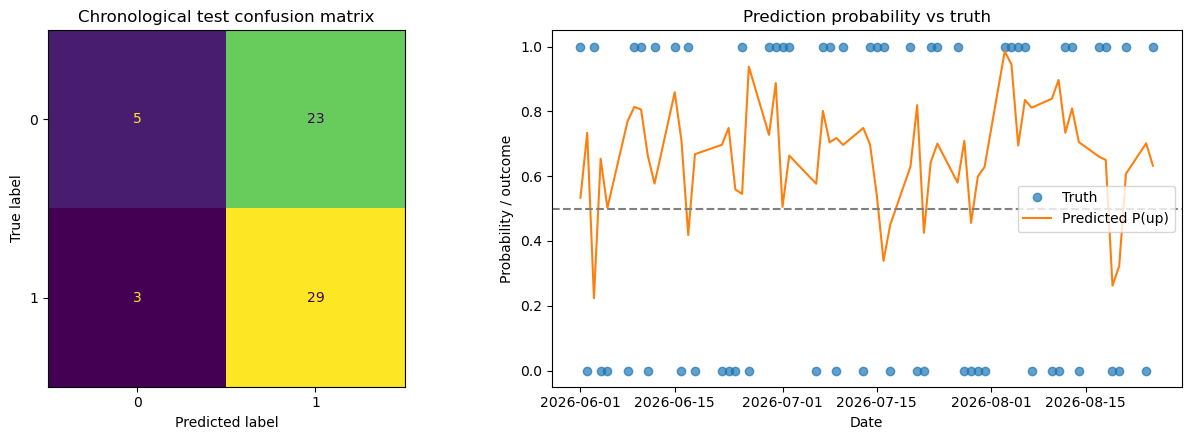

In [2]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5)); ConfusionMatrixDisplay.from_predictions(test.y_up,pred,ax=axes[0],colorbar=False); axes[0].set_title('Chronological test confusion matrix'); axes[1].plot(test.date,test.y_up,'o',label='Truth',alpha=.7); axes[1].plot(test.date,prob,label='Predicted P(up)'); axes[1].axhline(.5,color='gray',ls='--'); axes[1].set(title='Prediction probability vs truth',xlabel='Date',ylabel='Probability / outcome'); axes[1].legend(); plt.tight_layout(); plt.show()

Lag, rolling mean, rolling standard deviation, and momentum use `.shift(1)` before the target, so they cannot see the current or next-day outcome. The most recent 25% is held out, matching deployment better than random splitting. Performance near the majority-class rate indicates limited directional signal; precision and recall reveal whether apparent accuracy comes from favoring one class. The model can fail during regime changes, transaction costs make small edges unusable, and a single ticker/year is insufficient for production. This is a validated baseline, not trading advice.